<a href="https://colab.research.google.com/github/Mahmoud-Elseraty/SnailAI/blob/main/Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> From Model to Production</h1>
In this lesson we'll Try and learn how can we deploy a dummy model (CNN) onto huggingface using Gradio.
But fist things first we need to collect the Data, We'll be doing that using duckduckgo API.

In [22]:
import socket
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*datetime.utcnow.*")
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [23]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
iscolab = os.environ.get('COLAB_RELEASE_TAG', '')
if iskaggle:
    !pip install -Uqq fastai 'duckduckgo_search>=6.2'
if iscolab:
    !pip install -Uqq fastai 'ddgs'

# Step 1 : Download Your Data

In [24]:
import time, json
from ddgs import DDGS
from fastcore.all import *               #Trust me, it's no problem when using FastAI

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')

In [25]:
urls = search_images('Grizzly Bear', max_images=1)
urls[0]

'https://wallpapers.com/images/hd/grizzly-bear-pictures-2560-x-2048-o9hsfvsc9zfdzdu9.jpg'

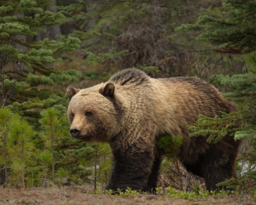

In [26]:
from fastdownload import download_url
dest = 'Test.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

In [47]:
searches = 'grizzly','polar','teddy'
path = Path('bears')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} bear photo',max_images=400))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


To remove all the failed images, you can use `unlink` on each of them. Note that, like most fastai functions that return a collection, `verify_images` returns an object of type `L`, which includes the `map` method. This calls the passed function on each element of the collection:

In [48]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

1

So now we should get to Data Cleaning Right? But it's gonna be hard to open each image and check whether its label is correct or not, So we'll build a model we can trust to distinct between labels.

# From Data to DataLoaders:

`DataLoaders` is a thin class that just stores whatever `DataLoader` objects you pass to it, and makes them available as `train` and `valid`. Although it's a very simple class, it's very important in fastai: it provides the data for your model.

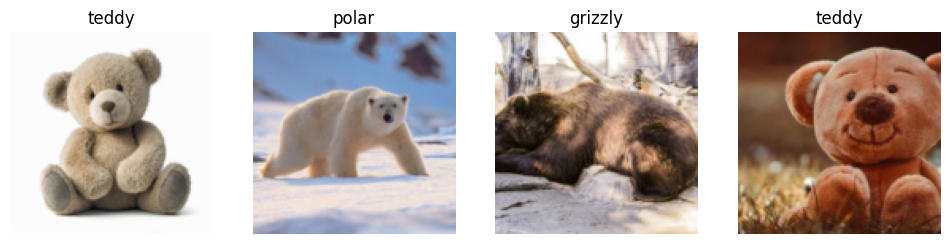

In [49]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.3, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

In [50]:
from collections import Counter

# Count items per category in the training set
train_categories = [dls.vocab[item[1]] for item in dls.train_ds]
train_category_counts = Counter(train_categories)
print("Training set category counts:", train_category_counts)

# Count items per category in the validation set
valid_categories = [dls.vocab[item[1]] for item in dls.valid_ds]
valid_category_counts = Counter(valid_categories)
print("Validation set category counts:", valid_category_counts)

Training set category counts: Counter({'grizzly': 140, 'teddy': 107, 'polar': 100})
Validation set category counts: Counter({'polar': 59, 'grizzly': 45, 'teddy': 44})


# Data Augmentation in FastAI

The `resize` method we used in the previous cell as default, will crop the image to the desired size by cropping it, we can try squishing the images so the whole image is presentable, we can also use `RandomResizedCrop` which gives the model (in training time) a whole lot of different augmented versions of the original image, Just like a preprocessing layer.

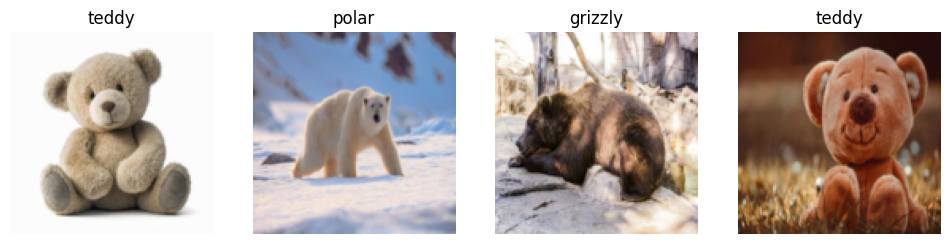

In [51]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

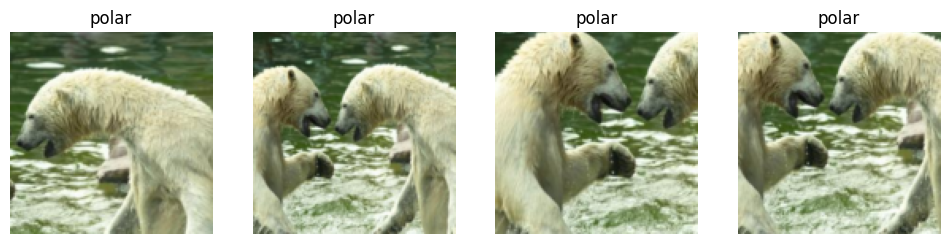

In [52]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1,unique=True)

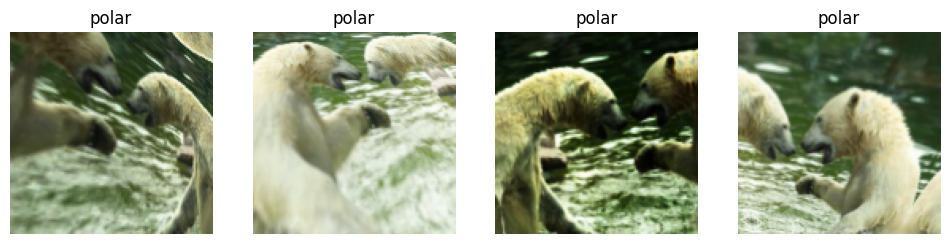

In [53]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

## Training Your Model, and Using It to Clean Your Data

We don't have a lot of data for our problem (150 pictures of each sort of bear at most), so to train our model, we'll use `RandomResizedCrop` with an image size of 224 px, which is fairly standard for image classification, and default `aug_transforms`:

In [54]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

In [55]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(5)

epoch,train_loss,valid_loss,error_rate,time
0,1.850573,0.075522,0.040541,00:03


epoch,train_loss,valid_loss,error_rate,time
0,0.114067,0.015992,0.006757,00:05
1,0.075602,0.028357,0.006757,00:02
2,0.061415,0.041533,0.006757,00:02
3,0.050332,0.042159,0.006757,00:02
4,0.039907,0.041126,0.006757,00:02


Now let's see whether the mistakes the model is making are mainly thinking that grizzlies are teddies (that would be bad for safety!), or that grizzlies are Polars, or something else. To visualize this, we can create a *confusion matrix*:

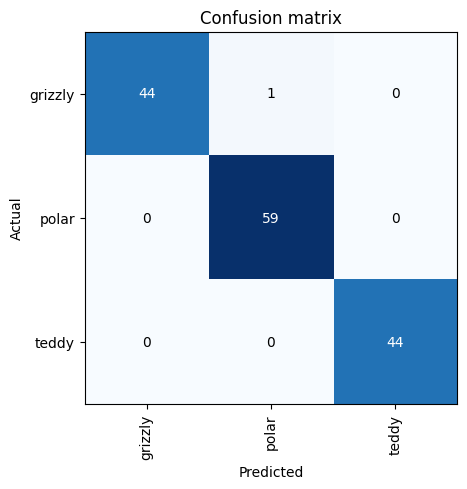

In [56]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Here there's one grizzly bear detected as a polar, It might not be the model's fault, it can be the searcher's fault, let's make sure.

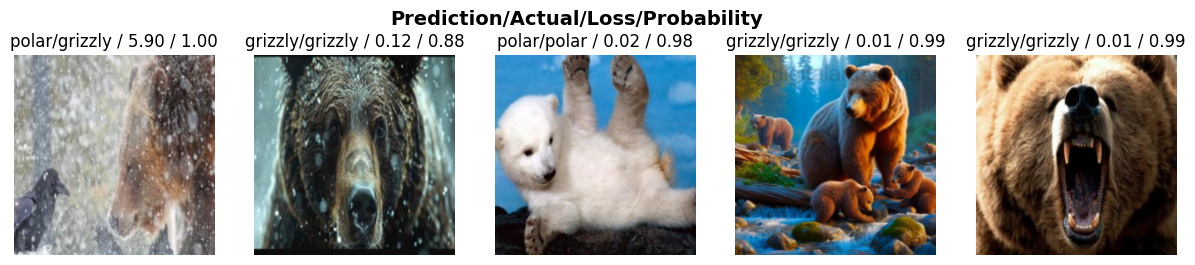

In [57]:
interp.plot_top_losses(5, nrows=1)

The Image wrongly detected can be seen at first, I'm not a bear specialist but it seems that the model was wrong, since it's actually a photo of a grizzly, we can check whether there's any other incompatible image by using the `cleaner` and giving it the model.

In [ ]:
from fastai.vision.widgets import *
cleaner = ImageClassifierCleaner(learn)
cleaner

# Exporting the model (.pkl)

Once you've got a model you're happy with, you need to save it, so that you can then copy it over to a server where you'll use it in production. Remember that a model consists of two parts: the *architecture* and the trained *parameters*. The easiest way to save the model is to save both of these, because that way when you load a model you can be sure that you have the matching architecture and parameters. To save both parts, use the `export` method.

This method even saves the definition of how to create your `DataLoaders`. This is important, because otherwise you would have to redefine how to transform your data in order to use your model in production. fastai automatically uses your validation set `DataLoader` for inference by default, so your data augmentation will not be applied, which is generally what you want.

When you call `export`, fastai will save a file called "export.pkl":

In [61]:
learn.export()
path = Path()
path.ls(file_exts='.pkl')

[Path('export.pkl')]

 You'll need this file wherever you deploy your app to. For now, let's try to create a simple app within our notebook.

When we use a model for getting predictions, instead of training, we call it *inference*. To create our inference learner from the exported file, we use `load_learner` (in this case, this isn't really necessary, since we already have a working `Learner` in our notebook; we're just doing it here so you can see the whole process end-to-end):

In [63]:
learn_inf = load_learner(path/'export.pkl')
learn_inf.predict(path/"Test.jpg")


('grizzly', tensor(0), tensor([1.0000e+00, 4.5634e-06, 1.2469e-07]))

We can see here that if we index into the vocab with the integer returned by `predict` then we get back "grizzly," as expected. Also, note that if we index into the list of probabilities, we see a nearly 1.00 probability that this is a grizzly.